#Extración de Datos

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import json_normalize
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

# Normalizar JSON anidado a tabla
df = json_normalize(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#Transformación

1.Comprobación de incoherencias en los datos

In [32]:
#Verificar valores nulos
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [33]:
#Ver si existen filas duplicadas
duplicados = df.duplicated().sum()
print("Filas duplicadas:", duplicados)

Filas duplicadas: 0


In [34]:
# Seleccionamos columnas de tipo object
categorical_cols = df.select_dtypes(include='object').columns

# Revisamos valores únicos de cada columna categórica
for col in categorical_cols:
    print(f"Columna: {col}")
    print(df[col].unique())
    print("-" * 30)

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
['No' 'Yes' '']
------------------------------
Columna: customer.gender
['Female' 'Male']
------------------------------
Columna: customer.Partner
['Yes' 'No']
------------------------------
Columna: customer.Dependents
['Yes' 'No']
------------------------------
Columna: phone.PhoneService
['Yes' 'No']
------------------------------
Columna: phone.MultipleLines
['No' 'Yes' 'No phone service']
------------------------------
Columna: internet.InternetService
['DSL' 'Fiber optic' 'No']
------------------------------
Columna: internet.OnlineSecurity
['No' 'Yes' 'No internet service']
------------------------------
Columna: internet.OnlineBackup
['Yes' 'No' 'No internet service']
------------------------------
Columna: internet.DeviceProtection
['No' 'Yes' 'No internet service']
------------------------------
Columna: internet.TechSupport
['

2.Manejo de inconsistencias

In [47]:
## Reemplazamos valores vacíos por NaN
df['Churn'] = df['Churn'].replace('', pd.NA)

# Revisamos cuantos faltantes(NaN) hay
df['Churn'].isna().sum()

np.int64(224)

In [48]:
#Convertimos la columna "account.Charges.Total" de string a number
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

#Revisamos que el cambio se haya realizado
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [46]:
#Reemplazamos
df.replace({
    'No internet service': 'No',
    'No phone service': 'No'
}, inplace=True)

#Verificamos los cambios
(df == 'No internet service').sum().sum()
(df == 'No phone service').sum().sum()

np.int64(0)

3.Columna de cuentas diarias

In [38]:
# Creamos la columna de cuentas diarias
df['Cuentas_Diarias'] = df['account.Charges.Total'] / (df['customer.tenure'] * 30)

# Si el cliente tiene tenure = 0, el resultado será infinito o NaN, así que podemos reemplazarlo por 0
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].fillna(0)

#Verificamos la columna añadida
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.971111


4.Estandarización y transformación de datos

In [39]:
# Encontramos columnas que tienen solo Yes/No
yes_no_cols_auto = [col for col in df.select_dtypes(include='object').columns
                    if set(df[col].dropna().unique()) <= {'Yes', 'No'}]

# Convertimos Yes → 1, No → 0
for col in yes_no_cols_auto:
    df[col] = df[col].map({'Yes': '1', 'No': '0'})

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.971111


In [14]:
#Renombramos algunas columna
df.rename(columns={
    'customer.gender': 'Genero',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'phone.PhoneService': 'Servicio_Telefono',
    'phone.MultipleLines': 'Lineas_Adicionales',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Movies',
    'account.Contract': 'Contrato',
    'account.PaperlessBilling': 'Facturacion_Sin_Papel',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Total': 'Cargos_Totales',
    'Cuentas_Diarias': 'Cuentas_Diarias',
    'Churn': 'Evasion'
}, inplace=True)
df.head()

,customerID,Evasion,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,Servicio_Telefono,Lineas_Adicionales,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Movies,Contrato,Facturacion_Sin_Papel,Metodo_Pago,account.Charges.Monthly,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.971111


# Carga y análisis

1.Anáalisis descriptivo

In [40]:
# Describe solo las columnas numéricas
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.155296
std,0.369074,24.571773,30.129572,2268.632997,1.010171
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.425000,400.225000,1.182167
50%,0.000000,29.000000,70.300000,1391.000000,2.340936
75%,0.000000,55.000000,89.875000,3785.300000,3.005805
max,1.000000,72.000000,118.750000,8684.800000,4.046667


In [41]:
df[['customer.tenure','account.Charges.Monthly','account.Charges.Total']].agg(['mean','median','std'])


,customer.tenure,account.Charges.Monthly,account.Charges.Total
mean,32.346498,64.720098,2280.634213
median,29.000000,70.300000,1391.000000
std,24.571773,30.129572,2268.632997


In [27]:
# Distribución de evasion
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)*100



,proportion
Churn,
0,73.463013
1,26.536987


In [28]:
# Distribución de generos
df['customer.gender'].value_counts()


,count
customer.gender,
Male,3675
Female,3592


In [29]:
#Distribución de contrato
df['account.Contract'].value_counts()

,count
account.Contract,
Month-to-month,4005
Two year,1743
One year,1519


2.Distribución de evasión

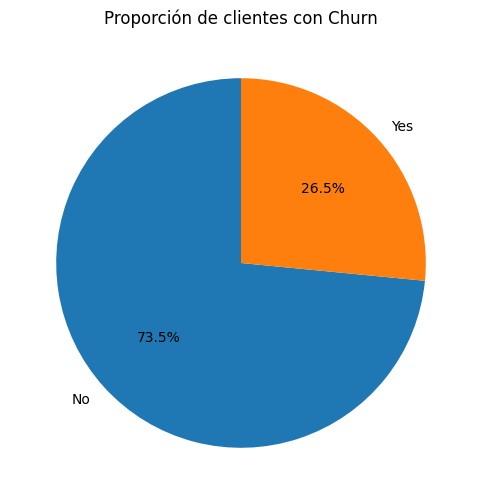

In [49]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Proporción de clientes con Churn')
plt.show()

3.Recuento de evasión por variables categóricas

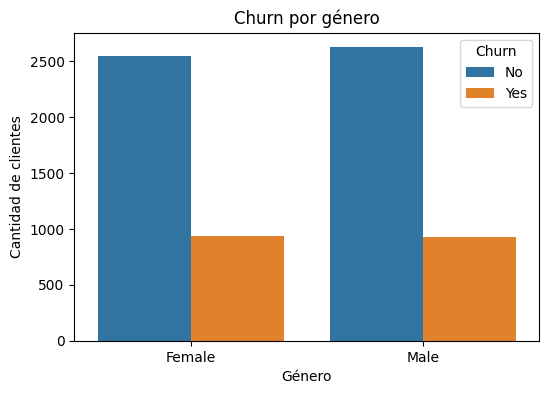

In [59]:
#churn por género
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='customer.gender', hue='Churn', data=df)

plt.title('Churn por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

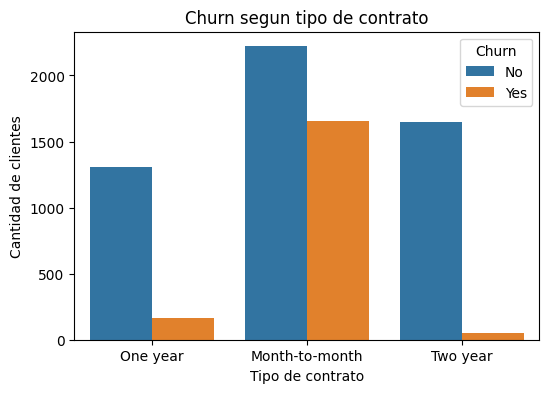

In [54]:
#churn por tipo de contrato
plt.figure(figsize=(6,4))
sns.countplot(x='account.Contract', hue='Churn', data=df)

plt.title('Churn segun tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

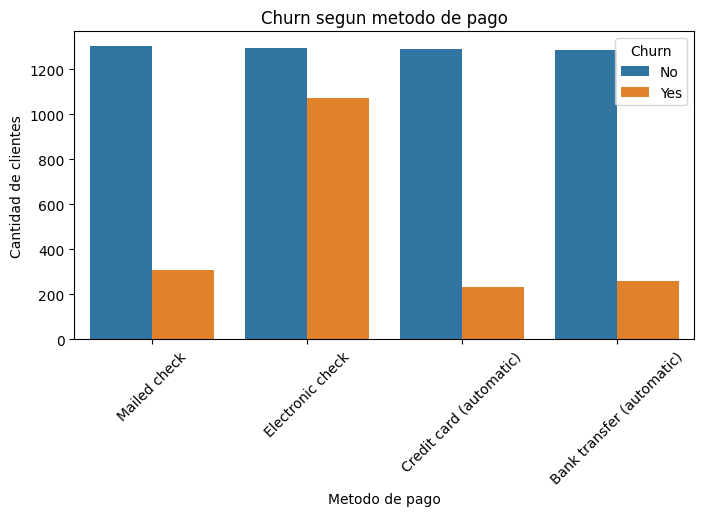

In [57]:
#churn por metodo de pago
plt.figure(figsize=(8,4))
sns.countplot(x='account.PaymentMethod', hue='Churn', data=df)

plt.title('Churn segun metodo de pago')
plt.xlabel('Metodo de pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)

plt.show()

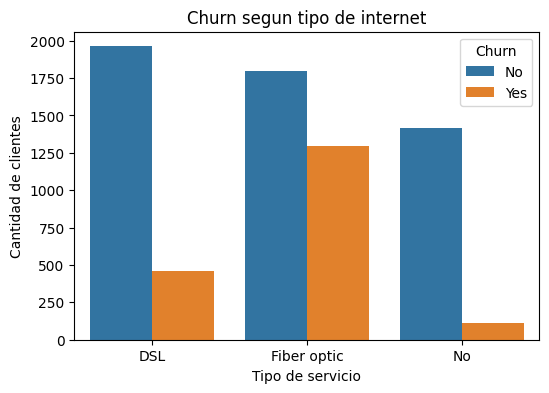

In [58]:
#churn por servicio de internet
plt.figure(figsize=(6,4))
sns.countplot(x='internet.InternetService', hue='Churn', data=df)

plt.title('Churn segun tipo de internet')
plt.xlabel('Tipo de servicio')
plt.ylabel('Cantidad de clientes')

plt.show()

4.Conteo de evasión por variables numérica

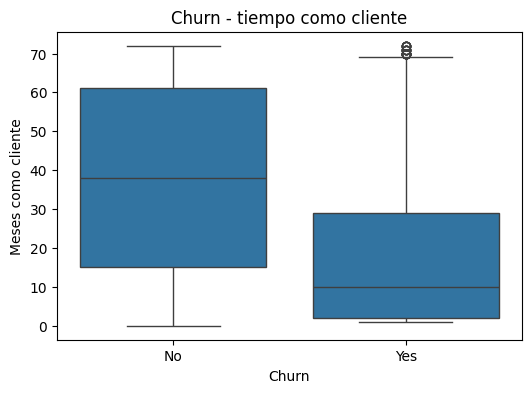

In [61]:
#churn - ternure
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer.tenure', data=df)

plt.title('Churn - tiempo como cliente')
plt.xlabel('Churn')
plt.ylabel('Meses como cliente')

plt.show()

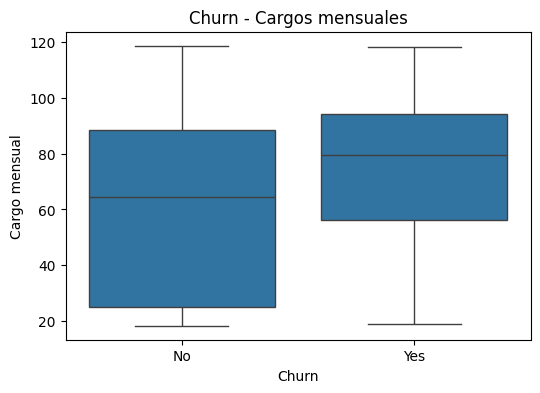

In [62]:
#churn charges monthly
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)

plt.title('Churn - Cargos mensuales')
plt.xlabel('Churn')
plt.ylabel('Cargo mensual')

plt.show()

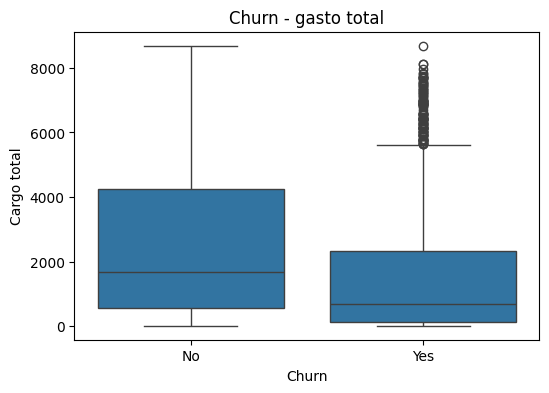

In [63]:
#churn - chargesw total
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Total', data=df)

plt.title('Churn - gasto total')
plt.xlabel('Churn')
plt.ylabel('Cargo total')

plt.show()

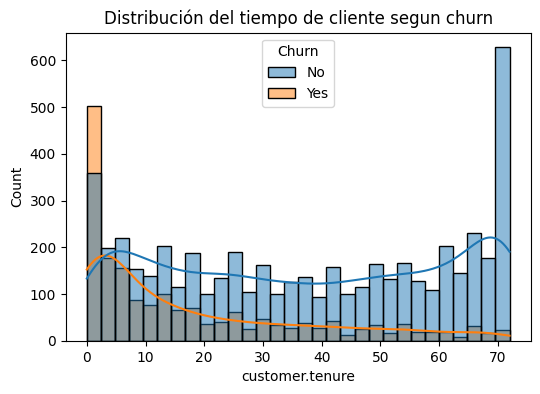

In [66]:
#Distribucion del tiempo de la cantidad de clientes segun churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='customer.tenure', hue='Churn', bins=30, kde=True)

plt.title('Distribución del tiempo de cliente segun churn')
plt.show()

#🔰Introducción

El objetivo de este análisis es estudiar el problema de evasión de clientes "Churn" en la empresa TelecomX. La evasión ocurre cuando un cliente decide cancelar el servicio, lo que representa una pérdida de ingresos para la empresa.

A través del análisis de datos se busca identificar patrones en el comportamiento de los clientes que abandonan el servicio.

Este tipo de análisis permite a las empresas comprender mejor a sus clientes y diseñar estrategias para reducir la evasión y mejorar la retención.

#🔰Limpieza y Tratamiento de Datos

Para preparar el conjunto de datos para el análisis, se realizaron varios pasos de limpieza y transformación:

* Normalización del JSON para convertir la estructura anidada en una tabla.

* Verificación de valores nulos para identificar datos faltantes.

* Detección de filas duplicadas para asegurar la calidad de los datos.

* Conversión de tipos de datos, particularmente la columna de cargos totales que fue transformada a formato numérico.

* Reemplazo de valores categóricos, sustituyendo etiquetas como “No internet service” y “No phone service” por “No” para simplificar el análisis.

* Creación de una nueva variable, llamada Cuentas_Diarias, que representa el gasto promedio diario del cliente.

* Conversión de variables binarias (Yes/No) a valores numéricos para facilitar el análisis.

* Renombrado de columnas para mejorar la claridad y comprensión del dataset.

Estos pasos permitieron obtener un conjunto de datos limpio y preparado para el análisis exploratorio.

#🔰Análisis Exploratorio de Datos

Durante el análisis exploratorio se estudiaron tanto variables categóricas como numéricas con el objetivo de identificar patrones relacionados con la evasión de clientes.

Primero se analizaron estadísticas descriptivas como media, mediana y desviación estándar para comprender la distribución de variables numéricas como:

* Tiempo de permanencia del cliente "ternure"

* cargos mensuales

* cargos totales.

Posteriormente se analizó la distribución de la variable de evasión "Churn" para identificar la proporción de clientes que cancelaron el servicio frente a los que permanecen.

También se realizaron análisis visuales para observar la relación entre churn y diferentes variables:

Variables categóricas como género, tipo de contrato, método de pago y servicios contratados.

Variables numéricas como tiempo de permanencia, cargos mensuales y gasto total.

Estos gráficos permitieron detectar tendencias y posibles factores asociados al abandono del servicio.

#🔰Conclusiones

A partir del análisis realizado se identificaron varios patrones importantes en el comportamiento de los clientes.

Se identificó que variables como el tiempo de permanencia del cliente tienen una relación importante con la evasión.

Asimismo, factores relacionados con los cargos mensuales y el gasto total pueden influir en la decisión de abandonar el servicio, ya que clientes con determinados niveles de gasto muestran comportamientos distintos respecto a la permanencia.

#🔰Recomendaciones

Fomentar contratos de mayor duración, ya que los clientes con contratos más largos suelen mostrar menor probabilidad de cancelar el servicio.

Implementar estrategias de retención para clientes nuevos, especialmente durante los primeros meses de servicio, cuando la probabilidad de evasión es mayor.

Analizar los cargos y planes de servicio, evaluando si ciertos niveles de precio influyen en la cancelación.